   cgpa  placement_exam_marks  placed
0  7.19                  26.0       1
1  7.46                  38.0       1
2  7.54                  40.0       1
3  6.42                   8.0       1
4  7.23                  17.0       0
     cgpa  placement_exam_marks  placed
995  8.87                  44.0       1
996  9.12                  65.0       1
997  4.89                  34.0       0
998  8.62                  46.0       1
999  4.90                  10.0       1
(1000, 3)
Index(['cgpa', 'placement_exam_marks', 'placed'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cgpa                  1000 non-null   float64
 1   placement_exam_marks  1000 non-null   float64
 2   placed                1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB
None
              cgpa  placement_exam_marks

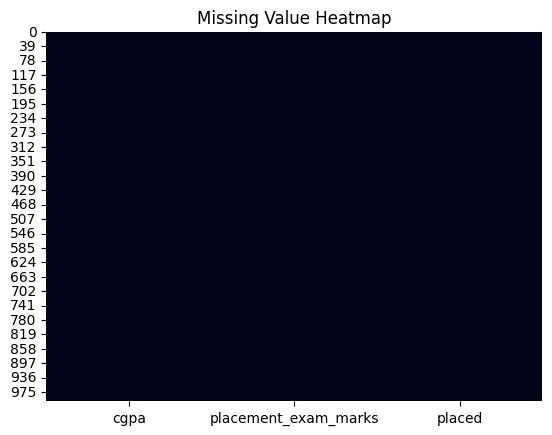

cgpa                    0
placement_exam_marks    0
placed                  0
dtype: int64
{0: 'Not Placed', 1: 'Placed'}
   placed placement_label
0       1          Placed
1       1          Placed
2       1          Placed
3       1          Placed
4       0      Not Placed


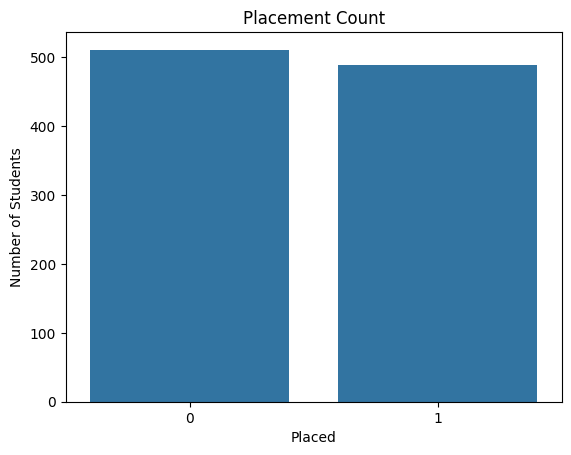

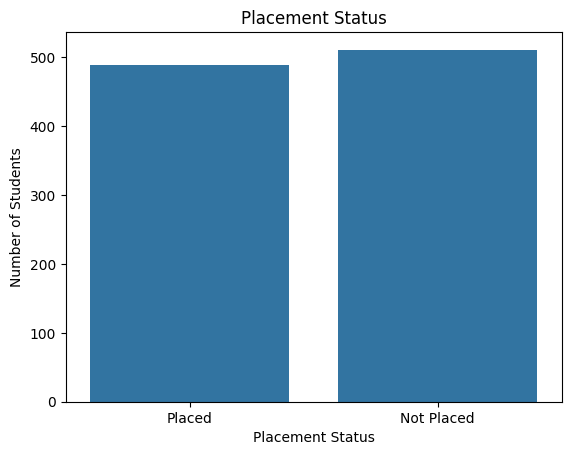

placed
0    511
1    489
Name: count, dtype: int64
Overall Placement Rate:
0.489
Average CGPA by Placement Status:
placement_label
Not Placed    6.944853
Placed        6.978364
Name: cgpa, dtype: float64


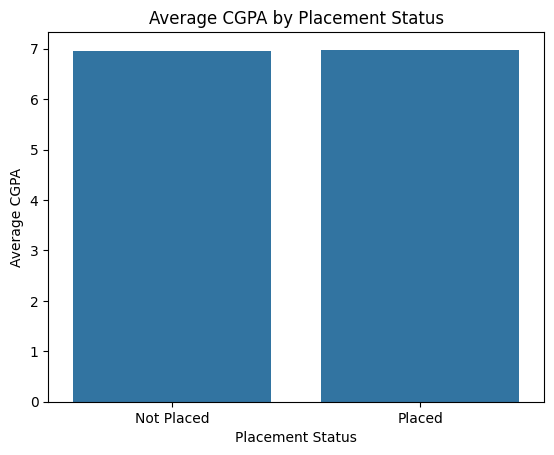

Average Placement Exam Marks by Placement Status:
placement_label
Not Placed    32.702544
Placed        31.725971
Name: placement_exam_marks, dtype: float64


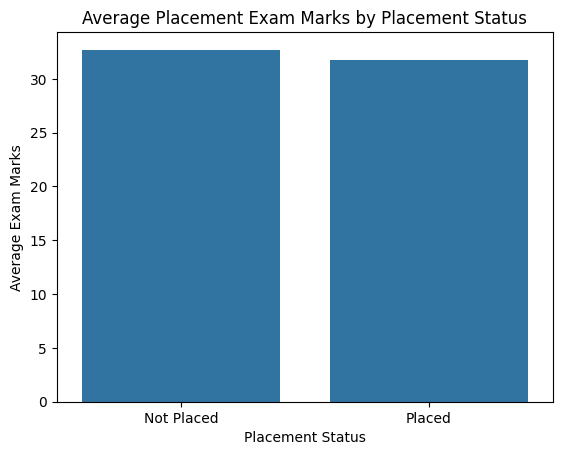

Placement Rate by CGPA Range:
cgpa_range
Below 6    0.428571
6-7        0.479915
7-8        0.505882
8-9        0.488889
9-10       1.000000
Name: placed, dtype: float64


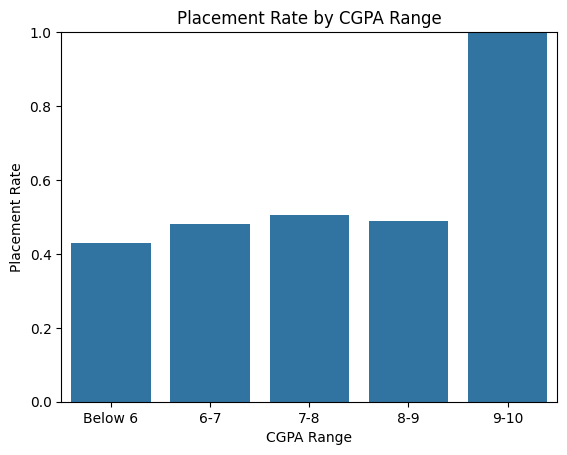

Placement Rate by Exam Marks:
exam_marks_range
Below 40    0.490754
40-50       0.471074
50-60       0.518519
60-70       0.461538
70-80       0.478261
80-100      0.473684
Name: placed, dtype: float64


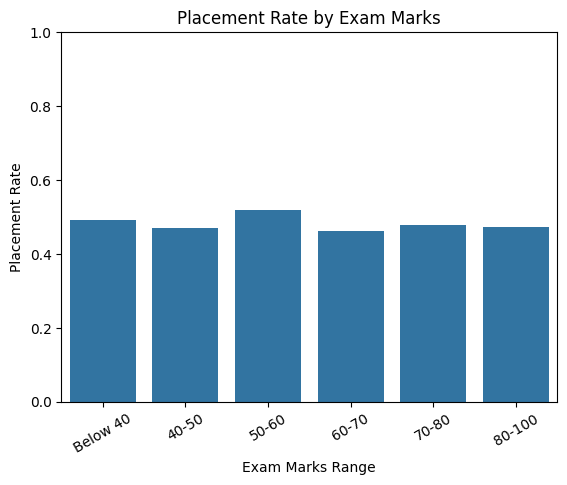

Correlation Matrix:
                          cgpa  placement_exam_marks    placed
cgpa                  1.000000             -0.027371  0.027212
placement_exam_marks -0.027371              1.000000 -0.025530
placed                0.027212             -0.025530  1.000000


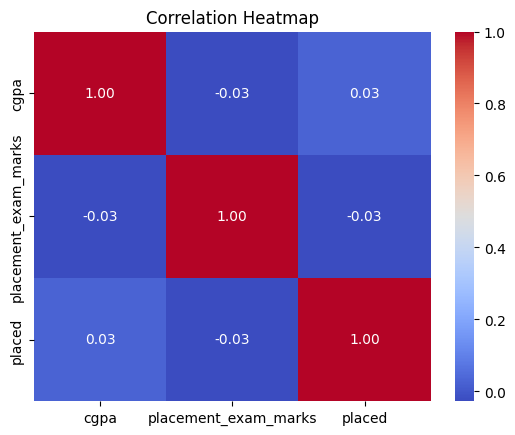

PDF created successfully
placement_eda_report.pdf


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

df = pd.read_csv("/content/placement.csv")

print(df.head())
print(df.tail())
print(df.shape)
print(df.columns)

print(df.info())
print(df.describe())
print(df.isnull().sum())

sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Value Heatmap")
plt.show()

df["cgpa"] = df["cgpa"].fillna(df["cgpa"].median())
df["placement_exam_marks"] = df["placement_exam_marks"].fillna(df["placement_exam_marks"].median())
df["placed"] = df["placed"].fillna(df["placed"].mode()[0])

print(df.isnull().sum())

placement_mapping = {
    0: "Not Placed",
    1: "Placed"
}

df["placement_label"] = df["placed"].map(placement_mapping)

print(placement_mapping)
print(df[["placed", "placement_label"]].head())

sns.countplot(x="placed", data=df)
plt.title("Placement Count")
plt.xlabel("Placed")
plt.ylabel("Number of Students")
plt.show()

sns.countplot(x="placement_label", data=df)
plt.title("Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Number of Students")
plt.show()

print(df["placed"].value_counts())

placement_rate = df["placed"].mean()

print("Overall Placement Rate:")
print(placement_rate)

cgpa_placement = df.groupby("placement_label")["cgpa"].mean()

print("Average CGPA by Placement Status:")
print(cgpa_placement)

sns.barplot(x=cgpa_placement.index, y=cgpa_placement.values)
plt.title("Average CGPA by Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Average CGPA")
plt.show()

exam_placement = df.groupby("placement_label")["placement_exam_marks"].mean()

print("Average Placement Exam Marks by Placement Status:")
print(exam_placement)

sns.barplot(x=exam_placement.index, y=exam_placement.values)
plt.title("Average Placement Exam Marks by Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Average Exam Marks")
plt.show()

df["cgpa_range"] = pd.cut(
    df["cgpa"],
    bins=[0, 6, 7, 8, 9, 10],
    labels=["Below 6", "6-7", "7-8", "8-9", "9-10"]
)

cgpa_analysis = df.groupby("cgpa_range", observed=False)["placed"].mean()

print("Placement Rate by CGPA Range:")
print(cgpa_analysis)

sns.barplot(x=cgpa_analysis.index, y=cgpa_analysis.values)
plt.title("Placement Rate by CGPA Range")
plt.xlabel("CGPA Range")
plt.ylabel("Placement Rate")
plt.ylim(0, 1)
plt.show()

df["exam_marks_range"] = pd.cut(
    df["placement_exam_marks"],
    bins=[0, 40, 50, 60, 70, 80, 100],
    labels=["Below 40", "40-50", "50-60", "60-70", "70-80", "80-100"]
)

exam_analysis = df.groupby("exam_marks_range", observed=False)["placed"].mean()

print("Placement Rate by Exam Marks:")
print(exam_analysis)

sns.barplot(x=exam_analysis.index, y=exam_analysis.values)
plt.title("Placement Rate by Exam Marks")
plt.xlabel("Exam Marks Range")
plt.ylabel("Placement Rate")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.show()

correlation = df[["cgpa", "placement_exam_marks", "placed"]].corr()

print("Correlation Matrix:")
print(correlation)

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

pdf = PdfPages("placement_eda_report.pdf")

fig = plt.figure(figsize=(8.27, 11.69))

plt.subplot(2, 1, 1)
plt.axis("off")
plt.text(
    0,
    1,
    "PLACEMENT DATASET EDA REPORT\n\n"
    + "Dataset Shape: "
    + str(df.shape)
    + "\n\nFirst 5 Rows:\n\n"
    + df.head().to_string(index=False),
    fontsize=9,
    verticalalignment="top"
)

plt.subplot(2, 1, 2)
sns.heatmap(df[["cgpa", "placement_exam_marks", "placed"]].isnull(), cbar=False, yticklabels=False)
plt.title("Missing Value Heatmap")

plt.tight_layout()
pdf.savefig(fig)
plt.close()

fig = plt.figure(figsize=(8.27, 11.69))

plt.subplot(2, 1, 1)
sns.countplot(x="placement_label", data=df)
plt.title("Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Number of Students")

plt.subplot(2, 1, 2)
sns.barplot(x=cgpa_placement.index, y=cgpa_placement.values)
plt.title("Average CGPA by Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Average CGPA")

plt.tight_layout()
pdf.savefig(fig)
plt.close()

fig = plt.figure(figsize=(8.27, 11.69))

plt.subplot(2, 1, 1)
sns.barplot(x=exam_placement.index, y=exam_placement.values)
plt.title("Average Placement Exam Marks by Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Average Exam Marks")

plt.subplot(2, 1, 2)
sns.barplot(x=cgpa_analysis.index, y=cgpa_analysis.values)
plt.title("Placement Rate by CGPA Range")
plt.xlabel("CGPA Range")
plt.ylabel("Placement Rate")
plt.ylim(0, 1)

plt.tight_layout()
pdf.savefig(fig)
plt.close()

fig = plt.figure(figsize=(8.27, 11.69))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Placement Dataset Correlation Heatmap")

plt.tight_layout()
pdf.savefig(fig)
plt.close()

pdf.close()

print("PDF created successfully")
print("placement_eda_report.pdf")